In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# inisideResults, outsideResults ; save these two to pickels 
import pickle
SAVE = False
LOAD = True

if SAVE:
    with open('noises_in_out/insideResults.pkl', 'wb') as f:
        pickle.dump(insideResults, f)
        
    with open('noises_in_out/outsideResults.pkl', 'wb') as f:
        pickle.dump(outsideResults, f)
        
        
if LOAD:
    with open('noises_in_out/insideResults.pkl', 'rb') as f:
        insideResults = pickle.load(f)
        
    with open('noises_in_out/outsideResults.pkl', 'rb') as f:
        outsideResults = pickle.load(f)

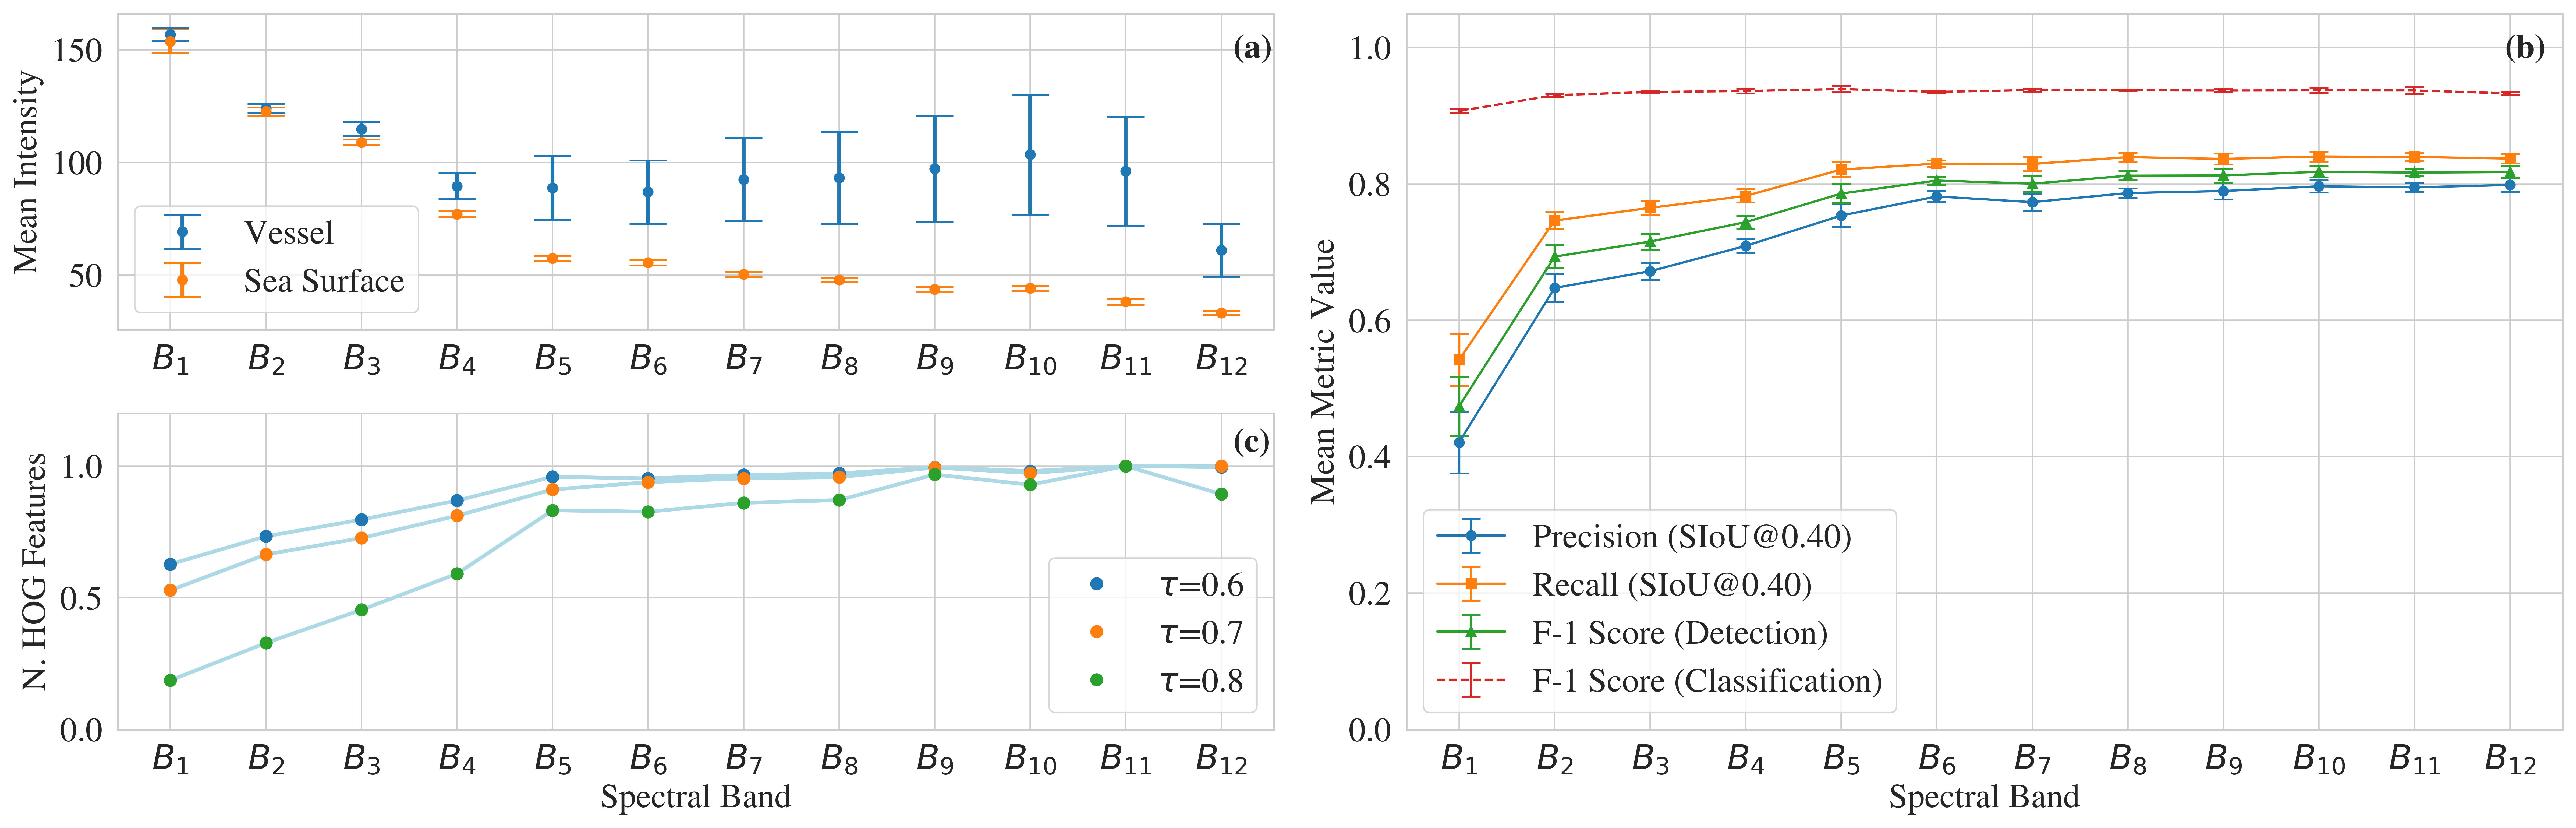

In [14]:
import matplotlib.pyplot as plt
from style import set_style
import numpy as np
import pandas as pd

set_style(scale_factor=1.3, fontsize=14)
threshold_value = 0.7

plt.subplot(2, 2, 1)
Band = 12
# Plot inside mean value with larger caps and lines
x = range(1, int(Band)+1)
xticks = [f'$B_{{{i}}}$' for i in x]
y = [insideResults[x][0]['mean'] for x in range(1, int(Band)+1)]
yerr = [insideResults[x][0]['std'] for x in range(1, int(Band)+1)]
plt.errorbar(x, y, yerr=yerr, fmt='o', label='Vessel', capsize=10, elinewidth=2)

# Plot outside mean value with larger caps and lines
y = [outsideResults[x][0]['mean'] for x in range(1, int(Band)+1)]
yerr = [outsideResults[x][0]['std'] for x in range(1, int(Band)+1)]
plt.errorbar(x, y, yerr=yerr, fmt='o', label='Sea Surface', capsize=10, elinewidth=2)

plt.ylabel('Mean Intensity')
plt.xticks(x, xticks)
plt.legend()

# Calculate the ratio of inside and outside mean values

# plt.subplot(2, 2, 2)
# Plot the ratio of mean values with larger caps and lines


# New Subplot: HOGS
plt.subplot(2, 2, 3)

def get_means_hog(band_num_hog):
    hog_features_by_band = [band_num_hog[band] for band in range(1, 13)]
    all_hog_features = np.concatenate(hog_features_by_band)
    min_val = np.min(all_hog_features)
    max_val = np.max(all_hog_features)
    normalized_all_hog_features = (all_hog_features - min_val) / (max_val - min_val)
    split_indices = np.cumsum([len(band) for band in hog_features_by_band[:-1]])
    normalized_hog_features_by_band = np.split(normalized_all_hog_features, split_indices)
    means = [np.mean(band) for band in normalized_hog_features_by_band]
    means = [i/np.max(means) for i in means]
    return means






threshold_value = 0.6
band_num_hog = pd.read_pickle(f'hog_results/band_num_hog_{threshold_value}.pkl')
means = get_means_hog(band_num_hog)
plt.plot(range(0, 12), means, linestyle='-', color='lightblue', linewidth=2) 
plt.errorbar(range(0, 12), means, yerr=None, fmt='o', capsize=10, elinewidth=2, capthick=1, markersize=6, label=f'$ \\tau $={threshold_value}')

threshold_value = 0.7
band_num_hog = pd.read_pickle(f'hog_results/band_num_hog_{threshold_value}.pkl')
means = get_means_hog(band_num_hog)
plt.plot(range(0, 12), means, linestyle='-', color='lightblue', linewidth=2) 
plt.errorbar(range(0, 12), means, yerr=None, fmt='o', capsize=10, elinewidth=2, capthick=1, markersize=6, label=f'$ \\tau $={threshold_value}')

threshold_value = 0.8
band_num_hog = pd.read_pickle(f'hog_results/band_num_hog_{threshold_value}.pkl')
means = get_means_hog(band_num_hog)
plt.plot(range(0, 12), means, linestyle='-', color='lightblue', linewidth=2) 
plt.errorbar(range(0, 12), means, yerr=None, fmt='o', capsize=10, elinewidth=2, capthick=1, markersize=6, label=f'$ \\tau $={threshold_value}')



# Customizing the plot
# plt.title('Distribution of HOG Features by Band')
plt.xlabel('Spectral Band')
plt.ylabel('N. HOG Features')
plt.legend()
plt.xticks(range(0, 12, 1), [f'$B_{{{i}}}$' for i in range(1, 13)])
plt.ylim([0.,1.2])




# New Subplot: Plot the ratio of inside to outside standard deviations
plt.subplot(1, 2, 2)

grouped = pd.read_pickle('grouped_single_venus.pkl')

# Plotting the error bars for each metric
plt.errorbar(grouped['Band'], grouped['mean_P'], yerr=grouped['std_P'], 
                label='Precision (SIoU@0.40)', fmt='-o', capsize=5)

plt.errorbar(grouped['Band'], grouped['mean_R'], yerr=grouped['std_R'], 
                label='Recall (SIoU@0.40)', fmt='-s', capsize=5)

plt.errorbar(grouped['Band'], grouped['mean_F1'], yerr=grouped['std_F1'], 
                label='F-1 Score (Detection)', fmt='-^', capsize=5)

classificationResults = {'Spectral Bands': {2: '$B_{1}$',
                            5: '$B_{2}$',
                            8: '$B_{3}$',
                            11: '$B_{4}$',
                            14: '$B_{5}$',
                            17: '$B_{6}$',
                            20: '$B_{7}$',
                            23: '$B_{8}$',
                            26: '$B_{9}$',
                            29: '$B_{10}$',
                            32: '$B_{11}$',
                            35: '$B_{12}$'},
                            'Metric': {2: "Cohen's Kappa",
                            5: "Cohen's Kappa",
                            8: "Cohen's Kappa",
                            11: "Cohen's Kappa",
                            14: "Cohen's Kappa",
                            17: "Cohen's Kappa",
                            20: "Cohen's Kappa",
                            23: "Cohen's Kappa",
                            26: "Cohen's Kappa",
                            29: "Cohen's Kappa",
                            32: "Cohen's Kappa",
                            35: "Cohen's Kappa"},
                            'Mean': {2: 0.906944453716278,
                            5: 0.930138885974884,
                            8: 0.9348611036936442,
                            11: 0.9362500111262004,
                            14: 0.9391666650772096,
                            17: 0.9350000023841858,
                            20: 0.9376388788223268,
                            23: 0.9373611211776732,
                            26: 0.9369444449742635,
                            29: 0.9372222224871316,
                            32: 0.9370833436648052,
                            35: 0.93277778228124},
                            'Std': {2: 0.0027708359311953,
                            5: 0.0024611071858073,
                            8: 0.0010393270430506,
                            11: 0.0035843103245184,
                            14: 0.0049065291353913,
                            17: 0.001360826337093,
                            20: 0.0022652204663452,
                            23: 0.0007081925829274,
                            26: 0.0020786965658063,
                            29: 0.0036057710187038,
                            32: 0.0047629199895355,
                            35: 0.0022135337548118}}

meanC = list(classificationResults['Mean'].values())
stdC = list(classificationResults['Std'].values())
plt.errorbar(grouped['Band'], meanC, yerr=stdC, 
                label='F-1 Score (Classification)', fmt='--', capsize=5)

plt.ylim([0.,1.05])
plt.ylabel('Mean Metric Value')
plt.xlabel('Spectral Band')
plt.xticks(range(0, 12, 1), [f'$B_{{{i}}}$' for i in range(1, 13)])
plt.legend(loc='best')
plt.tight_layout()

# add text (a), (b), (c)
plt.text(-0.15, .97, '(a)', transform=plt.gca().transAxes, fontsize=18, fontweight='bold', va='top')
plt.text(.95, .97, '(b)', transform=plt.gca().transAxes, fontsize=18, fontweight='bold', va='top')
plt.text(-0.15, .42, '(c)', transform=plt.gca().transAxes, fontsize=18, fontweight='bold', va='top')
plt.savefig('/Data_large/marine/PythonProjects/MMDET/results/Fig9.png')
plt.show()

In [10]:
classificationResults

{'Spectral Bands': {2: '$B_{1}$',
  5: '$B_{2}$',
  8: '$B_{3}$',
  11: '$B_{4}$',
  14: '$B_{5}$',
  17: '$B_{6}$',
  20: '$B_{7}$',
  23: '$B_{8}$',
  26: '$B_{9}$',
  29: '$B_{10}$',
  32: '$B_{11}$',
  35: '$B_{12}$'},
 'Metric': {2: "Cohen's Kappa",
  5: "Cohen's Kappa",
  8: "Cohen's Kappa",
  11: "Cohen's Kappa",
  14: "Cohen's Kappa",
  17: "Cohen's Kappa",
  20: "Cohen's Kappa",
  23: "Cohen's Kappa",
  26: "Cohen's Kappa",
  29: "Cohen's Kappa",
  32: "Cohen's Kappa",
  35: "Cohen's Kappa"},
 'Mean': {2: 0.906944453716278,
  5: 0.930138885974884,
  8: 0.9348611036936442,
  11: 0.9362500111262004,
  14: 0.9391666650772096,
  17: 0.9350000023841858,
  20: 0.9376388788223268,
  23: 0.9373611211776732,
  26: 0.9369444449742635,
  29: 0.9372222224871316,
  32: 0.9370833436648052,
  35: 0.93277778228124},
 'Std': {2: 0.0027708359311953,
  5: 0.0024611071858073,
  8: 0.0010393270430506,
  11: 0.0035843103245184,
  14: 0.0049065291353913,
  17: 0.001360826337093,
  20: 0.002265220466